Programació per a *Data Science*
============================

Unitat 4: Biblioteques científiques en Python - Matplotlib
------------------------------------------------------

Instruccions d'ús
-----------------

A continuació es presentaran explicacions i exemples d'ús de la
biblioteca Matplotlib. Recordeu que podeu anar executant els exemples per
obtenir-ne els resultats.

Introducció
-----------

El codi de Matplotlib està dividit en tres parts: *pylab*, *Matplotlib
API* i *backends*. La primera part, *pylab*, és la interfície que permet
crear gràfics amb un codi i funcionament molt similar a com es faria en
Matlab. *Matplotlib API* és la part essencial que la resta de codi
utilitza i, finalment, *backends* és la part encarregada de la
representació depenent de la plataforma (tipus de fitxers d'imatge,
dispositius de visualització, etc.). En aquest mòdul només farem
exemples i exercicis utilitzant *pylab*.

Podeu consultar molts exemples a l'[ajuda de la
biblioteca](http://matplotlib.org/1.3.1/examples/index.html).

Exemple 1: representar la funció cosinus
----------------------------------------

Al primer exemple representarem dos _arrays_, un davant de l'altre, als
eixos X i Y respectivament. **Observeu que per fer que els gràfics
es mostrin en el mateix Notebook hem d'afegir la directiva especial**
*%matplotlib inline*.

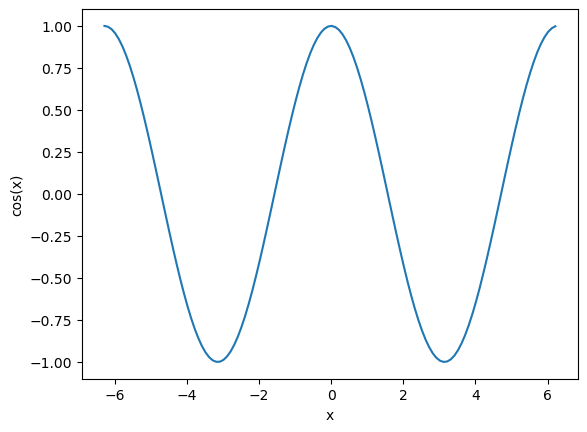

In [1]:
%matplotlib inline

# Aquest primer import és necessari per inicialitzar l'entorn de Matplotlib.
import matplotlib
import numpy as np
# Importem la biblioteca utilitzant l'àlies 'plt'.
import matplotlib.pyplot as plt

# Calculem una matriu de -2*PI a 2*PI amb un pas de 0.1.
x = np.arange(-2*np.pi, 2*np.pi, 0.1)

# Representem l'array x amb el valor de cos(x).
plt.plot(x, np.cos(x))

# Afegim els noms als eixos X i Y respectivament:
plt.xlabel('x')
plt.ylabel('cos(x)')

# Finalment mostrarem el gràfic:
plt.show()

Exemple 2: representar les funcions cosinus i sinus alhora
----------------------------------------------------------

En aquest exemple, calcularem els valors de les funcions sinus i cosinus
per al mateix rang de valors i les representarem al mateix gràfic.

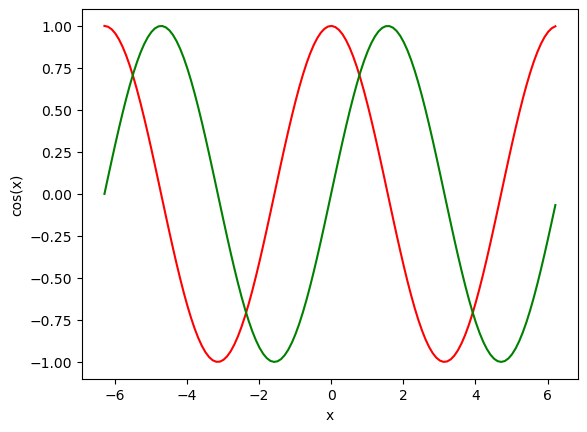

In [2]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Calculem una matriu de -2*PI a 2*PI amb un pas de 0.1.
x = np.arange(-2*np.pi, 2*np.pi, 0.1)

# Podem encadenar la representació de múltiples funcions al mateix gràfic.
# En aquest ordre: array x, cos(x), 'r' farà servir el color vermell (red), 
# array x, sin(x) i verd (green)
plt.plot(x, np.cos(x), 'r', x, np.sin(x), 'g')

# De manera equivalent, podríem fer una crida en dues ocasions a la funció plot:
#plt.plot(x, np.cos(x), 'r')
#plt.plot(x, np.sin(x), 'g')

# Afegim els noms als eixos X i Y respectivament:
plt.xlabel('x')
plt.ylabel('cos(x)')

# Finalment, mostrarem el gràfic.
plt.show()

Exemple 3: histogrames
----------------------

Matplotlib disposa de molts tipus de gràfics implementats, entre els
quals hi ha els histogrames. En aquest exemple representem una [funció
gaussiana](https://es.wikipedia.org/wiki/Funci%C3%B3n_gaussiana).

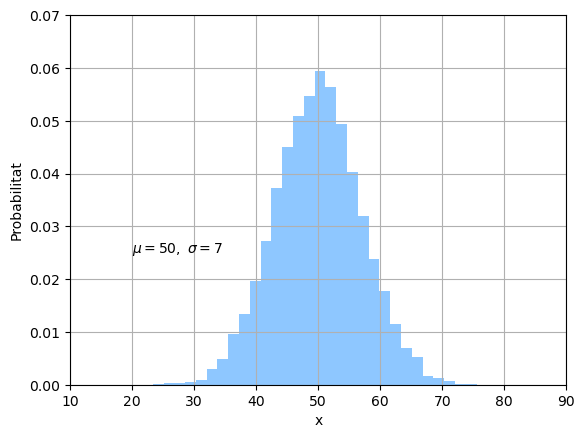

In [3]:
%matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab

# Paràmetres de la funció gaussiana:
mu, sigma = 50, 7

# Generem una matriu utilitzant aquests paràmetres i nombres aleatoris.
x = mu + sigma * np.random.randn(10000)

# La funció 'hist' calcula la freqüència i el nombre de barres. L'argument
# 'normed = 1' normalitza els valors de probabilitat ([0,1]), 'facecolor'
# controla el color del gràfic, i 'alpha', el valor de la transparència de les
# barres.
n, bins, patches = plt.hist(x, 30, density=1, facecolor='dodgerblue', alpha=0.5)

plt.xlabel('x')
plt.ylabel('Probabilitat')

# Situem el text amb els valors de 'mu' i 'sigma' al gràfic:
plt.text(20, .025, r'$\mu=50,\ \sigma=7$')

# Controlem manualment la mida dels eixos. Els dos primers valors es corresponen
# amb 'xmin' i 'xmax' i els següents amb 'ymin' i 'ymax':
plt.axis([10, 90, 0, 0.07])

# Mostrem una reixeta:
plt.grid(True)

plt.show()

Exemple 4: representació del conjunt de Mandelbrot
--------------------------------------------------

El conjunt de Mandelbrot és un dels conjunts fractals més estudiats i
coneguts. Podeu trobar més informació en línia sobre [el conjunt i els
fractals en
general](https://es.wikipedia.org/wiki/Conjunto_de_Mandelbrot).

L'exemple és una adaptació d'[aquest codi](https://scipy-lectures.github.io/intro/numpy/exercises.html#mandelbrot-set).

/var/folders/_q/tkvyvtz15715rzzgkj8hjxjm0000gn/T/ipykernel_37955/611936090.py:20: RuntimeWarning: overflow encountered in square
  z = z**2 + c
/var/folders/_q/tkvyvtz15715rzzgkj8hjxjm0000gn/T/ipykernel_37955/611936090.py:20: RuntimeWarning: invalid value encountered in square
  z = z**2 + c


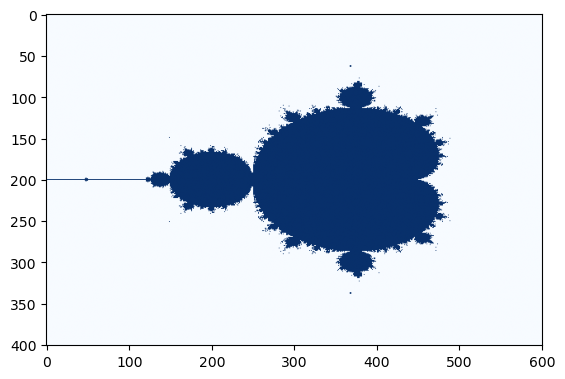

In [4]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from numpy import newaxis

# La funció que calcularà el conjunt de Mandelbrot.
def mandelbrot(N_max, threshold, nx, ny):
    # Creem una matriu amb nx elements entre els valors -2 i 1.
    x = np.linspace(-2, 1, nx)
    # Fem el mateix, però, en aquest cas, entre -1.5 i 1.5, de ny elements.
    y = np.linspace(-1.5, 1.5, ny)

    # Creem el pla de nombres complexos necessari per calcular el conjunt.
    c = x[:,newaxis] + 1j*y[newaxis,:]

    # Iteració per calcular el valor d'un element en la successió.
    z = c
    for j in range(N_max):
        z = z**2 + c
    
    # Finalment, calculem si un element pertany o no al conjunt posant un límit
    # 'threshold'.
    conjunto = (abs(z) < threshold)
    
    return conjunto

conjunto_mandelbrot = mandelbrot(50, 50., 601, 401)

# Transposem els eixos del conjunt de Mandelbrot calculat utilitzant la funció
# de NumPy 'T'. Utilitzem la funció 'imshow' per representar una matriu com una
# imatge. L'argument 'cmap' significa 'color map' i és l'escala de colors en què
# representarem la nostra imatge. Podeu trobar molts altres mapes a la
# documentació oficial: 
# http://matplotlib.org/examples/color/colormaps_reference.html
plt.imshow(conjunto_mandelbrot.T, cmap='Blues')

plt.show()

Exemple 5: manipulació d'imatges
--------------------------------

Una imatge pot assimilar-se a una matriu multidimensional en què pels valors
de píxels (x, y) tenim calors de color. Matplotlib ens permet llegir
imatges, manipular-les i aplicar-hi diferents mapes de colors a
l'hora de representar-les. A l'exemple següent, carregarem una
fotografia en format PNG de Carl Sagan.

Crèdits de la foto: NASA JPL

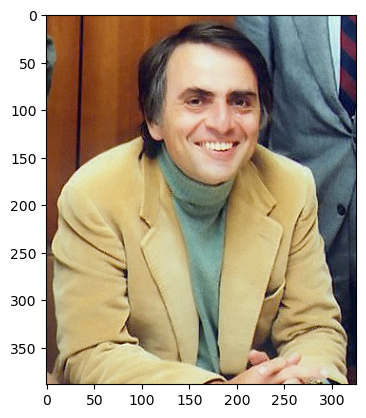

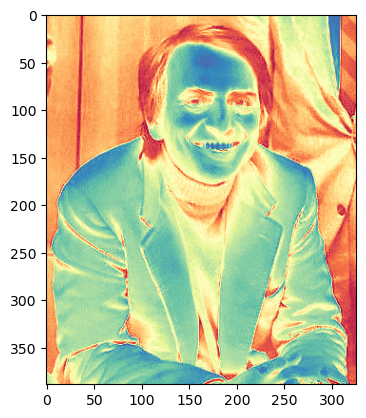

In [5]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Llegim la imatge mitjançant la funció 'imread'.
carl = mpimg.imread('media/sagan.png')

# Podem mostrar la imatge:
plt.imshow(carl)
plt.show()

# I podem modificar els valors numèrics de color llegits per la funció 'imread'.
# Obtenim els valors de l'escala de grisos i mostrem els valors fent servir el
# mapa de colors espectrals.
gris = np.mean(carl, 2)
plt.imshow(gris, cmap='Spectral')
plt.show()